In [55]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Inspect missing values
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [56]:

# Fix TotalCharges (empty string -> NaN)
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Fill NaN with median
df.fillna(df['TotalCharges'].median(), inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop CustomerID
df = df.drop(columns=['customerID'])

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)
 
print("")
print(df.isnull().sum())



SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingM

In [57]:

# Split features & target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [58]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



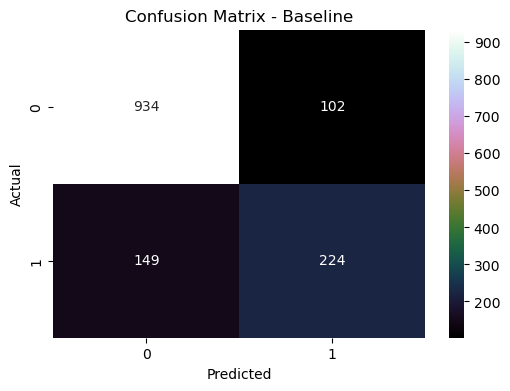

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train baseline model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

# Predict
y_pred = baseline_model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='cubehelix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline')
plt.show()


In [60]:
from sklearn.metrics import f1_score

results = []

Cs = [0.01, 0.1, 1, 10]

for C in Cs:
    # L1
    model_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)
    model_l1.fit(X_train, y_train)
    y_pred = model_l1.predict(X_test)
    results.append(['L1', C, f1_score(y_test, y_pred)])

    # L2
    model_l2 = LogisticRegression(penalty='l2', C=C, max_iter=1000)
    model_l2.fit(X_train, y_train)
    y_pred = model_l2.predict(X_test)
    results.append(['L2', C, f1_score(y_test, y_pred)])

# No regularization
model_none = LogisticRegression(penalty=None, max_iter=1000)
model_none.fit(X_train, y_train)
y_pred = model_none.predict(X_test)
results.append(['None', '-', f1_score(y_test, y_pred)])

# Convert to DataFrame69
results_df = pd.DataFrame(results, columns=['Penalty', 'C', 'F1 Score'])
print(results_df)

  Penalty     C  F1 Score
0      L1  0.01  0.555735
1      L2  0.01  0.608563
2      L1   0.1  0.640580
3      L2   0.1  0.632801
4      L1     1  0.640916
5      L2     1  0.640916
6      L1    10  0.638968
7      L2    10  0.637016
8    None     -  0.633094


In [61]:
best = results_df.sort_values(by='F1 Score', ascending=False).iloc[0]
print(best)

Penalty           L1
C                  1
F1 Score    0.640916
Name: 4, dtype: object


In [62]:
# Misal model terbaik disimpan sebagai best_model
best_model = model_l1  # ganti sesuai hasil terbaik

coeffs = pd.Series(best_model.coef_[0], index=X.columns)
top_features = coeffs.abs().sort_values(ascending=False).head(10)
print(top_features)

InternetService_Fiber optic       1.577674
Contract_Two year                 1.454107
tenure                            1.382644
MultipleLines_No phone service    1.178010
PhoneService_Yes                  1.161003
InternetService_No                1.063200
MonthlyCharges                    1.029150
TotalCharges                      0.685498
Contract_One year                 0.651627
StreamingMovies_Yes               0.599555
dtype: float64


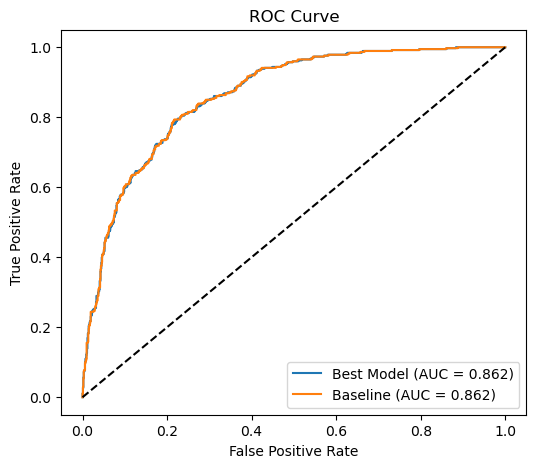

0.8621593155775462
0.8619264131998716


In [65]:
from sklearn.metrics import roc_curve, auc

# Best model probability
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Baseline probability
y_prob_base = baseline_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

auc_best = auc(fpr_best, tpr_best)
auc_base = auc(fpr_base, tpr_base)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr_best, tpr_best, label=f'Best Model (AUC = {auc_best:.3f})')
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {auc_base:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


print(auc_base)
print(auc_best)